In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
from langchain.callbacks.base import BaseCallbackHandler

class MyCallbackHandler(BaseCallbackHandler):
    def on_agent_action(self, action, **kwargs):
        print(f"[on_agent_action] action: {action}")

    def on_agent_finish(self, finish, **kwargs):
        print(f"[on_agent_finish] finish: {finish}")

    def on_tool_start(self, serialized, input_str, **kwargs):
        # print(f"[on_tool_start] tool: {serialized}, input: {input_str}")
        print(f"[on_tool_start] tool: {serialized.get('name')}, input: {input_str}")
        # serialized.get('name', '기본값')은 호출될 도구의 이름
        # serialized['name'] 대신
        # get() 메서드를 사용하면 'name' 속성이 없는 경우 오류가 발생하는 대신 None을 반환하거나 지정한 기본값을 반환

    def on_tool_end(self, output, **kwargs):
        print(f"[on_tool_end] tool: {output}")

    def on_llm_start(self, serialized, prompts, **kwargs):
        # print(f"[on_llm_start] llm: {serialized}, input: {prompts}")
        print(f"[on_llm_start] llm: {serialized.get('id')}, input: {prompts[0]}")
        # 'id'는 언어 모델의 식별자로서 모듈 경로와 클래스 이름이 내용(리스트 형식으로 표시)
        # prompts는 리스트인데 on_llm_start()는 일반 언어 모델에 해당이 되므로 하나의 프롬프트만 전달
        # 따라서, prompts[0]를 사용하여 프롬프트 내용을 확인할 수 있음
    
    def on_llm_end(self, response, **kwargs):
        # print(f"[on_llm_end] output: {response}")
        print(f"[on_llm_end] output: {response.generations[0][0].text}")
        # response.generations[0][0].text는 언어 모델이 생성한 순수한 텍스트 출력

    def on_chat_model_start(self, serialized, messages, **kwargs):
        # print(f"[on_chat_model_start] chat model: {serialized}, input: {messages}")
        print(f"[on_llm_start] llm: {serialized.get('id')}, input: {messages}")
        # serialized.get('id')는 채팅 모델의 식별자로서 모듈 경로와 클래스 이름이 내용
        # messages는 채팅 모델에 전달될 대화 기록 전체를 담고 있는 리스트

    def on_chain_start(self, serialized, inputs, **kwargs):

        runnable_id = None
        runnable_type = None
        runnable_name = None

        if isinstance(serialized, dict):
            if "id" in serialized:
                if isinstance(serialized["id"], list):
                    runnable_id = ".".join(serialized["id"])
                else:
                    runnable_id = str(serialized["id"])

            runnable_type = serialized.get("type")
            runnable_name = serialized.get("name")
        if runnable_id is not None:
            # print(f"[on_chain_start] id={runnable_id}, type={runnable_type}, name={runnable_name}, inputs={inputs}")
            print(f"[on_chain_start] id={runnable_id}, inputs={inputs}")

    def on_chain_end(self, outputs, **kwargs):
        serialized = kwargs.get('serialized', {})
        runnable_id = None
        runnable_type = None
        runnable_name = None

        if isinstance(serialized, dict):
            if "id" in serialized:
                if isinstance(serialized["id"], list):
                    runnable_id = ".".join(serialized["id"])
                else:
                    runnable_id = str(serialized["id"])

            runnable_type = serialized.get("type")
            runnable_name = serialized.get("name")

        if runnable_id is not None:
            # print(f"[on_chain_end] id={runnable_id}, type={runnable_type}, name={runnable_name}, outputs={outputs}")
            print(f"[on_chain_end] id={runnable_id}, outputs={outputs}")

In [ ]:
# PythonREPLTool
# python -m pip install langchain_experimental

# REPL은 Read-Eval-Print Loop
# 대화형 프로그래밍 환경을 의미(파이썬도 해당)

# PythonREPLTool은 이 REPL 환경을 LangChain 에이전트가 사용할 수 있도록 만든 도구
# 언어 모델은 코드를 작성하고, 외부 도구인 PythonREPLTool은 그 코드를 실행하는 역할

In [ ]:
# 대부분의 외부 도구 (PythonREPLTool 등)는 Runnable을 직접 구현하지 않음 > Runnable이 아님
# 따라서 LCEL의 파이프라인이나 invoke() 방식으로는 바로 사용할 수 없음
# 외부 도구는 기본적으로 직접 호출이 가능하지만, 특정 상황에서는 Runnable로 변환하는 것이 필요하거나 유리

# 1. 도구와 다른 Runnable과 |로 연결하여 기존 LangChain 흐름에 통합
# 2. 콜백을 통한 추적 관리

In [ ]:
# 1. 독립적인 도구로 직접 사용하기 (언어 모델 사용하지 않음)

from langchain_experimental.tools import PythonREPLTool

# PythonREPLTool 인스턴스 생성
repl = PythonREPLTool()

# 한 줄에 여러 구문을 작성할 때에는 ;을 사용해서 구분
print("예제 1: 리스트 정렬 결과")
sort_code = "data = [3, 1, 4, 1, 5, 9]; data.sort(); print(data)"
result_sort = repl.run(sort_code)
print(result_sort)
print("-" * 30)

print("예제 2: 수학 라이브러리 사용")
math_code = "import math; print(math.sqrt(144))"
result_math = repl.run(math_code)
print(result_math)
print("-" * 30)

print("예제 3: 문자열 조작")
string_code = """
text = "hello langchain world"
upper_text = text.upper()
print(upper_text)
"""
result_string = repl.run(string_code)
print(result_string)
print("-" * 30)

print("예제 4: 조건문 사용")
conditional_code = """
score = 85
if score >= 90:
    print("A")
elif score >= 80:
    print("B")
else:
    print("C")
"""
result_conditional = repl.run(conditional_code)
print(result_conditional)

In [ ]:
# 2. 에이전트 없이 LCEL(LangChain Expression Language) 체인의 한 단계로 사용
# Runnable로 바꾸기 - RunnableLambda 사용하기 - 1

from langchain_experimental.tools import PythonREPLTool
from langchain_core.runnables import RunnableLambda

python_repl_tool = PythonREPLTool()
python_repl_runnable = RunnableLambda(lambda code: python_repl_tool.run(code))
result = python_repl_runnable.invoke("print('Hello, ' + 'World!')")

print(f"변환된 Runnable 실행 결과: {result}")

In [ ]:
# Runnable로 바꾸기 - RunnableLambda 사용하기 - 2

from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_core.output_parsers import StrOutputParser

python_repl_tool = PythonREPLTool()
python_repl_runnable = RunnableLambda(lambda code: python_repl_tool.run(code))

llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")
prompt = PromptTemplate.from_template("다음 계산을 위한 파이썬 코드를 작성하세요. 결과만 출력하는 코드를 작성해주세요. 100 * 25")

chain = prompt | llm | StrOutputParser() | python_repl_runnable

result = chain.invoke({}, config={"callbacks": [MyCallbackHandler()]})

print(f"체인 실행 결과: {result}")

In [ ]:
# Router 패턴 - 복습

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableLambda, RunnableBranch, RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

# Router를 위한 LLM과 프롬프트 정의
# LLM에게 질문의 유형을 "general" 또는 "python"으로 분류하도록 지시
router_llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")

# {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
# 변수 {question} -> {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}
router_prompt = PromptTemplate.from_template("""
주어진 질문이 "파이썬(python)" 관련 질문인지, 또는 "일반(general)" 질문인지 판단하세요.
답변은 오직 'python' 또는 'general'만으로 작성해야 합니다.

질문: {question}
""")

# 각 경로(path)에 해당하는 체인 정의

#{"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
general_chain = PromptTemplate.from_template("다음 질문에 친절하게 답변해주세요: {question}") | router_llm | StrOutputParser()
# {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
python_chain = PromptTemplate.from_template("다음 질문에 대한 파이썬 코드를 작성해주세요: {question}") | router_llm | StrOutputParser()

# 사용자의 질문을 router_llm에 보내고, router_llm의 출력이 'python'인지 'general'인지 확인

router_chain = router_prompt | router_llm | StrOutputParser()

# RunnableBranch
# (condition, runnable_if_true, runnable_if_false) 형태로 사용됩니다.

# 입력: {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
# router_chain에게 invoke를 통해서 넘기는 값: {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}

# router_branch = RunnableBranch(
#     (lambda x: "python" in router_chain.invoke({"question": x["question"]["question"]}).lower(), python_chain),
#     # 
#     general_chain
# )

# 입력: {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
router_branch = RunnableBranch(
    (lambda x: "python" in router_chain.invoke({"question": x["question"]["question"]}).lower(), 
     {"question": lambda x: x["question"]["question"]} | python_chain),
    {"question": lambda x: x["question"]["question"]} | general_chain
)

# 입력: {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}
# {"question": {"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}}
final_chain = {"question": RunnablePassthrough()} | router_branch

# router_branch에서 router_chain를 실행
# router_chain의 router_prompt에서 on_chain_start 콜백
# 원래는 on_chain_start router_chain ... 이지만
# router_chain의 첫 번째 runnable인 router_prompt의 on_chain_start와 중복

print("=== 첫 번째 실행: 파이썬 질문 ===")
result1 = final_chain.invoke({"question": "2의 10승을 계산하는 파이썬 코드를 작성해줘."}, \
                             config={"callbacks": [MyCallbackHandler()]})
print(f"결과: {result1}\n")

print("=== 두 번째 실행: 일반 질문 ===")
result2 = final_chain.invoke({"question": "인공지능이란 무엇인가요?"}, \
                             config={"callbacks": [MyCallbackHandler()]})
print(f"결과: {result2}")

In [ ]:
# 2. Agent와 함께 사용하기
# ReAct (Reasoning and Acting) 기반 에이전트: create_react_agent()

from langchain_openai import ChatOpenAI
from langchain_experimental.tools import PythonREPLTool
from langchain.agents import AgentExecutor, create_react_agent
from langchain import hub
from langchain_core.prompts import PromptTemplate

tools = [PythonREPLTool()]

prompt = hub.pull("hwchase17/react")

llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

agent = create_react_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

result1 = agent_executor.invoke({"input": "What is the 10th fibonacci number?"})
print(f"최종 답변: {result1['output']}\n")

# tools = [PythonREPLTool()]을 사용할지 말지의 결정은 언어 모델이 함
result2 = agent_executor.invoke({"input": "2 곱하기 3은?"})
print(f"최종 답변: {result2['output']}")


# Thought
# Final Answer
# Final Answer 앞의 Thought는 도구 결과를 검증하는 과정에서 나온 언어 모델의 출력

In [ ]:

# 2. Agent와 함께 사용하기
# 구조화된 출력(Structured Output) 기반 에이전트: create_tool_calling_agent()

from langchain_openai import ChatOpenAI
from langchain_experimental.tools import PythonREPLTool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain import hub

tools = [PythonREPLTool()]

# 2. 에이전트 프롬프트 정의
#    - 'system'과 'human' 메시지를 정의하여 LLM의 역할을 명확히 합니다.
#    - MessagesPlaceholder를 사용하여 대화 기록과 에이전트의 중간 단계를 포함시킵니다.
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant. Use tools to answer questions."),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)

# 3. LLM 및 에이전트 생성
#    - LLM은 tool_calling 기능을 지원하는 모델이어야 합니다.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

#    - create_tool_calling_agent() 함수로 에이전트를 생성합니다.
#    - 이 함수는 LLM, 도구, 프롬프트를 받아 Runnable 객체를 반환합니다.
agent = create_tool_calling_agent(llm, tools, prompt)

# 4. AgentExecutor 생성
#    - AgentExecutor는 에이전트의 실행을 관리합니다.
#    - verbose=True로 설정하면 에이전트의 작동 과정을 볼 수 있습니다.
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

# 5. 에이전트 실행
print("=== 에이전트 실행: 10의 10승 계산 ===")
result = agent_executor.invoke({"input": "10의 10승은 얼마야?"})
print(f"\n최종 답변: {result['output']}")


# Invoking: `Python_REPL` with `{'query': '10**10'}`라고 함

In [ ]:
# def sum(a, b)라는 함수가 있고 이 함수가 Tool로 래핑
# 언어 모델은 도구 호출을 위해 {'a': ..., 'b': ...} 형태의 딕셔너리를 생성

In [ ]:
# PythonREPLTool 클래스에 정의된 메타데이터를 통해 PythonREPLTool의 run 메서드는 run(self, query: str, **kwargs)임을 파악
# def run_python_code(code: str) -> str

# 언어 모델은 {'query': *}이고 {'code': *}의 형식으로 출력
# 출력은 {'code': *} 이지만 run_python_code의 시그니처를 확인하고 'code'에 해당하는 값만 추출 > Tool 객체가 담당

# Agent가 Tool.func를 보고 {'code': *}의 형식으로 AgentAction을 생성
# AgentExecutor가 Tool 객체에 전달
# Tool 객체는 전달 받은 내용에서 run_python_code 함수가 요구하는 단일 값('1010')을 추출하여 함수에 전달

# Invoking: `Python_REPL` with `{'query': '10**10'}`은 Agent로부터 전달받은 내용을 기초로 AgentExecutor가 출력한 내용이므로 틀린 것은 아님
# 문제는 PythonREPLTool 호출을 할 때 '10**10'을 넘겼어야 한다는 점
# 딕셔너리에서 값을 빼내는 작업을 안 한 것은 AgentExecutor (LangChain 프레임워크는 딕셔너리 기반, PythonREPLTool은 단일 문자열 기반 입력)
# 따라서 Tool 객체로 하여금 그 일을 대신하게 한 것

In [27]:
# 10의 10승 문제 해결하기

from langchain_openai import ChatOpenAI
from langchain_experimental.tools import PythonREPLTool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.callbacks import BaseCallbackHandler
from langchain_core.tools import Tool

def run_python_code(code: str) -> str:
    """Python 코드를 실행하고 결과를 반환합니다."""
    try:
        python_tool = PythonREPLTool()
        result = python_tool.run(code)
        return f"실행 결과: {result}"
    except Exception as e:
        return f"오류 발생: {str(e)}"

# Tool 객체로 래핑
python_tool_wrapper = Tool(
    name="python_executor",
    description="Python 코드를 실행합니다. 계산, 데이터 처리 등에 사용하세요.",
    func=run_python_code
)

tools = [python_tool_wrapper]
# 언어 모델이 아는 정보
# Tool 이름 (name), Tool 설명 (description), Tool 스키마(args_schema)
# 언어 모델이 모르는 정보
# 실제 함수(func) 내부 로직


# 프롬프트 개선
prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 도움이 되는 어시스턴트입니다. 
    계산이나 코딩이 필요한 질문에는 python_executor 도구를 사용하세요.
    간단한 질문은 도구 없이 답변할 수 있습니다."""),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

# LLM 설정
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Tool Calling Agent 생성
agent = create_tool_calling_agent(llm, tools, prompt)

# AgentExecutor 설정 (무한루프 방지)
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    max_iterations=5,
    callbacks=[MyCallbackHandler()]
)


In [28]:

try:
    result1 = agent_executor.invoke({"input": "10의 10승을 계산해주세요"})
    print(f"최종 답변: {result1['output']}\n")
except Exception as e:
    print(f"오류: {e}\n")

# 아래 셀에서 계속



> Entering new AgentExecutor chain...
[on_agent_action] action: tool='python_executor' tool_input='10**10' log='\nInvoking: `python_executor` with `10**10`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_8jkkDkRjzXKLo2nOItN3YLoK', 'function': {'arguments': '{"__arg1":"10**10"}', 'name': 'python_executor'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_51db84afab', 'service_tier': 'default'}, id='run--ab44531f-7b8c-495f-804b-8b6dcc5d75f5', tool_calls=[{'name': 'python_executor', 'args': {'__arg1': '10**10'}, 'id': 'call_8jkkDkRjzXKLo2nOItN3YLoK', 'type': 'tool_call'}], tool_call_chunks=[{'name': 'python_executor', 'args': '{"__arg1":"10**10"}', 'id': 'call_8jkkDkRjzXKLo2nOItN3YLoK', 'index': 0, 'type': 'tool_call_chunk'}])] tool_call_id='call_8jkkDkRjzXKLo2nOItN3YLoK'

Invoking: `python_executor` with `10**10`


실행 결과: [on_agent_finish]

In [ ]:

try:
    result2 = agent_executor.invoke({"input": "1부터 100까지의 합을 구해주세요"})
    print(f"최종 답변: {result2['output']}\n")
except Exception as e:
    print(f"오류: {e}\n")

# 아래 셀에서 계속

In [ ]:
try:
    result3 = agent_executor.invoke({"input": "안녕하세요!"})
    print(f"최종 답변: {result3['output']}\n")
except Exception as e:
    print(f"오류: {e}\n")

In [ ]:
from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

question = "123456789에 100을 곱한 후 7로 나눈 나머지는?"
print(f"질문: {question}")
result = agent_executor.invoke({"input": question}, callbacks=[MyCallbackHandler()])

print(result)

# `Python_REPL` with `{'query': 'result = (123456789 * 100) % 7\nresult'}`
# `Python_REPL` with `{'query': '123456789 * 100'}`
# 123456789에 100을 곱한 값은 12345678900이고, 이 값을 7로 나눈 나머지는 4입니다.

# 모두 언어 모델의 출력이지만 
# tool_input의 차이

In [19]:
from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 도구의 결과를 그대로 사용자에게 전달하는 로봇 어시스턴트입니다."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

question = "오늘로부터 100일 뒤의 날짜와 요일을 알려줘."
print(f"질문: {question}")
agent_executor.invoke({"input": question}, callbacks=[MyCallbackHandler()])

# Invoking: `Python_REPL` with `{'query': "from datetime import datetime, timedelta\n\n# 
# 현재 날짜\ncurrent_date = datetime.now()\n\n# 100일 뒤의 날짜\nfuture_date = current_date + timedelta(days=100)\n\n
# # 100일 뒤의 요일\nfuture_day_of_week = future_date.strftime('%A')\n\nfuture_date, future_day_of_week"}`
# 은 언어모델의 출력

# responded: 죄송합니다. 무언가 잘못되었습니다. 잠시만 기다려 주세요.
# 

질문: 오늘로부터 100일 뒤의 날짜와 요일을 알려줘.


> Entering new AgentExecutor chain...
[on_agent_action] action: tool='Python_REPL' tool_input={'query': "from datetime import datetime, timedelta\n\n# 현재 날짜\ncurrent_date = datetime.now()\n\n# 100일 뒤의 날짜\nfuture_date = current_date + timedelta(days=100)\n\n# 100일 뒤의 요일\nfuture_day_of_week = future_date.strftime('%A')\n\nfuture_date, future_day_of_week"} log='\nInvoking: `Python_REPL` with `{\'query\': "from datetime import datetime, timedelta\\n\\n# 현재 날짜\\ncurrent_date = datetime.now()\\n\\n# 100일 뒤의 날짜\\nfuture_date = current_date + timedelta(days=100)\\n\\n# 100일 뒤의 요일\\nfuture_day_of_week = future_date.strftime(\'%A\')\\n\\nfuture_date, future_day_of_week"}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_cOXiuGkhQRDQ8Pn3ocq6aGPK', 'function': {'arguments': '{"query": "from datetime import datetime, timedelta\\n\\n# 현재 날짜\\ncurrent_date = datetime.now()\\n\\n# 100일 뒤의 날짜\\nfuture_date = curre

{'input': '오늘로부터 100일 뒤의 날짜와 요일을 알려줘.',
 'output': '죄송합니다. 현재 시스템에 문제가 발생하여 날짜와 요일을 제공할 수 없습니다. 나중에 다시 시도해 주세요.'}

In [20]:
# 언어 모델의 차이

from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

# ChatOpenAI는 틀린 대답
# llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
llm=ChatGoogleGenerativeAI(model="gemini-2.0-flash")
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 도구의 결과를 그대로 사용자에게 전달하는 로봇 어시스턴트입니다."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

question = "오늘로부터 100일 뒤의 날짜와 요일을 알려줘."
print(f"질문: {question}")
agent_executor.invoke({"input": question}, callbacks=[MyCallbackHandler()])

질문: 오늘로부터 100일 뒤의 날짜와 요일을 알려줘.


> Entering new AgentExecutor chain...
[on_agent_action] action: tool='Python_REPL' tool_input={'query': "import datetime\nnow = datetime.datetime.now()\nfuture = now + datetime.timedelta(days=100)\nprint(future.strftime('%Y-%m-%d %A'))"} log='\nInvoking: `Python_REPL` with `{\'query\': "import datetime\\nnow = datetime.datetime.now()\\nfuture = now + datetime.timedelta(days=100)\\nprint(future.strftime(\'%Y-%m-%d %A\'))"}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'function_call': {'name': 'Python_REPL', 'arguments': '{"query": "import datetime\\nnow = datetime.datetime.now()\\nfuture = now + datetime.timedelta(days=100)\\nprint(future.strftime(\'%Y-%m-%d %A\'))"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--74dce3d2-73d4-4a36-b1ce-72ba885e063f', tool_calls=[{'name': 'Python_REPL', 'args': {'query': "import datetime\nnow = datetime.datetime.now()\nfuture = now +

{'input': '오늘로부터 100일 뒤의 날짜와 요일을 알려줘.',
 'output': '오늘로부터 100일 뒤는 2025년 12월 30일 화요일입니다.\n'}

In [23]:
# 프롬프트 (systemMessage)의 차이

from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 웹 크롤링을 잘하는 에이아이야"),
    # ("system", "너는 네이버페이 증권 사이트를 어떻게 scrawling하는지 잘 알고 있어"),
    # ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

question = "삼성전자의 현재 주가를 알려줘." 
# 언어 모델은 주가 조회를 하려면 yfinance를 사용해야 한다는 것을 학습
# python -m pip install yfinance
# 현재 삼성전자 주가는 79,700

print(f"질문: {question}")
agent_executor.invoke({"input": question})


# ("system", "너는 웹 크롤링을 잘하는 에이아이야"),
# ("system", "너는 네이버페이 증권 사이트를 어떻게 scrawling하는지 잘 알고 있어"), 실패
# ("system", "You are a helpful assistant."), 의 경우 yfinance로 문제 해결을 시도

질문: 삼성전자의 현재 주가를 알려줘.


> Entering new AgentExecutor chain...
[on_agent_action] action: tool='Python_REPL' tool_input={'query': "import yfinance as yf\n\n# Get the data for the stock SAMSUNG ELECTRONICS (005930.KS)\nsamsung = yf.Ticker('005930.KS')\n\n# Get the current price\ncurrent_price = samsung.history(period='1d')['Close'][0]\n\nprint(current_price)"} log='\nInvoking: `Python_REPL` with `{\'query\': "import yfinance as yf\\n\\n# Get the data for the stock SAMSUNG ELECTRONICS (005930.KS)\\nsamsung = yf.Ticker(\'005930.KS\')\\n\\n# Get the current price\\ncurrent_price = samsung.history(period=\'1d\')[\'Close\'][0]\\n\\nprint(current_price)"}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_vfXnBjA9xHnzLZDEuUDinS85', 'function': {'arguments': '{"query": "import yfinance as yf\\n\\n# Get the data for the stock SAMSUNG ELECTRONICS (005930.KS)\\nsamsung = yf.Ticker(\'005930.KS\')\\n\\n# Get the current price\\ncurrent_price = s

<string>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


79700.0
[on_agent_action] action: tool='Python_REPL' tool_input={'query': "import requests\nfrom bs4 import BeautifulSoup\n\n# URL of the stock page\nurl = 'https://finance.yahoo.com/quote/005930.KS'\n\n# Send a GET request to the URL\nresponse = requests.get(url)\n\n# Parse the HTML content of the page\nsoup = BeautifulSoup(response.content, 'html.parser')\n\n# Find the current price from the parsed content\ncurrent_price = soup.find_all('span', {'data-reactid': '50'})[0].text\n\nprint(current_price)"} log='\nInvoking: `Python_REPL` with `{\'query\': "import requests\\nfrom bs4 import BeautifulSoup\\n\\n# URL of the stock page\\nurl = \'https://finance.yahoo.com/quote/005930.KS\'\\n\\n# Send a GET request to the URL\\nresponse = requests.get(url)\\n\\n# Parse the HTML content of the page\\nsoup = BeautifulSoup(response.content, \'html.parser\')\\n\\n# Find the current price from the parsed content\\ncurrent_price = soup.find_all(\'span\', {\'data-reactid\': \'50\'})[0].text\\n\\nprint

<string>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


79700.0
[on_agent_finish] finish: return_values={'output': '현재 삼성전자의 주가는 79,700원입니다.'} log='현재 삼성전자의 주가는 79,700원입니다.'
현재 삼성전자의 주가는 79,700원입니다.

> Finished chain.


{'input': '삼성전자의 현재 주가를 알려줘.', 'output': '현재 삼성전자의 주가는 79,700원입니다.'}

질문: 주어진 데이터(10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10)를 사용하여 간단한 히스토그램을 그려줘.


> Entering new AgentExecutor chain...


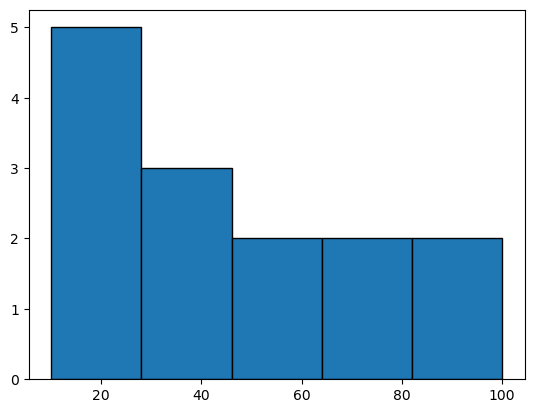

[on_agent_action] action: tool='Python_REPL' tool_input={'query': "import matplotlib.pyplot as plt\n\ndata = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10]\nplt.hist(data, bins=5, edgecolor='black')\nplt.show()"} log='\nInvoking: `Python_REPL` with `{\'query\': "import matplotlib.pyplot as plt\\n\\ndata = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10]\\nplt.hist(data, bins=5, edgecolor=\'black\')\\nplt.show()"}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_bZPNOQ0giRmLIR9olLYrRoqq', 'function': {'arguments': '{"query": "import matplotlib.pyplot as plt\\n\\ndata = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10]\\nplt.hist(data, bins=5, edgecolor=\'black\')\\nplt.show()"}', 'name': 'Python_REPL'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-1106', 'system_fingerprint': 'fp_982035f36f', 'service_tier': 'default'}, id='run--58d6f91f-a5fa-430

{'input': '주어진 데이터(10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10)를 사용하여 간단한 히스토그램을 그려줘.',
 'output': '여기 간단한 히스토그램이야.'}

In [24]:
from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

# 아래 요청에 matplotlib을 사용하는 시도를 함
# conda install matplotlib

question = "주어진 데이터(10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 10, 20, 30, 10)를 사용하여 간단한 히스토그램을 그려줘."
print(f"질문: {question}")
agent_executor.invoke({"input": question}, callbacks=[MyCallbackHandler()])

In [25]:
# 프롬프트에서 이미지 저장 위치 이야기 하지 않으면 이미지 생성 하지 않음

from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

# import qrcode를 시도
# conda install qrcode

question = "https://www.github.com을 QR코드 이미지로 만들어줘. \
    만든 이미지는 C:\\Users\\bayesian\\Desktop\\Collection\\아이티고동영상\\LangChain_P4에 저장해"
print(f"질문: {question}")
agent_executor.invoke({"input": question})

질문: https://www.github.com을 QR코드 이미지로 만들어줘.     만든 이미지는 C:\Users\bayesian\Desktop\Collection\아이티고동영상\LangChain_P4에 저장해


> Entering new AgentExecutor chain...
[on_agent_action] action: tool='Python_REPL' tool_input={'query': "import qrcode\nimg = qrcode.make('https://www.github.com')\nimg.save('C:\\\\Users\\\\bayesian\\\\Desktop\\\\Collection\\\\아이티고동영상\\\\LangChain_P4\\\\github_qr.png')"} log='\nInvoking: `Python_REPL` with `{\'query\': "import qrcode\\nimg = qrcode.make(\'https://www.github.com\')\\nimg.save(\'C:\\\\\\\\Users\\\\\\\\bayesian\\\\\\\\Desktop\\\\\\\\Collection\\\\\\\\아이티고동영상\\\\\\\\LangChain_P4\\\\\\\\github_qr.png\')"}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_e32xcrKx6vXAvVhq79kXtEkR', 'function': {'arguments': '{"query": "import qrcode\\nimg = qrcode.make(\'https://www.github.com\')\\nimg.save(\'C:\\\\\\\\Users\\\\\\\\bayesian\\\\\\\\Desktop\\\\\\\\Collection\\\\\\\\아이티고동영상\\\\\\\\LangChain_P4\\\\\\\\gi

{'input': 'https://www.github.com을 QR코드 이미지로 만들어줘.     만든 이미지는 C:\\Users\\bayesian\\Desktop\\Collection\\아이티고동영상\\LangChain_P4에 저장해',
 'output': 'QR 코드 이미지가 성공적으로 생성되었고, C:\\Users\\bayesian\\Desktop\\Collection\\아이티고동영상\\LangChain_P4 경로에 저장되었습니다.'}

In [26]:
from langchain_experimental.tools import PythonREPLTool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain.prompts import ChatPromptTemplate

llm = ChatOpenAI(model="gpt-3.5-turbo-1106", temperature=0)
tools = [PythonREPLTool()]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, callbacks=[MyCallbackHandler()])

# python -m pip install fpdf
question = "문서 제목은 'My First PDF'로 하고, 내용에는 'Hello, Python REPL Tool!'이라는 텍스트가 담긴 간단한 PDF 파일을 만들어줘."
print(f"질문: {question}")
agent_executor.invoke({"input": question}, callbacks=[MyCallbackHandler()])

질문: 문서 제목은 'My First PDF'로 하고, 내용에는 'Hello, Python REPL Tool!'이라는 텍스트가 담긴 간단한 PDF 파일을 만들어줘.


> Entering new AgentExecutor chain...
[on_agent_action] action: tool='Python_REPL' tool_input={'query': 'from fpdf import FPDF\npdf = FPDF()\npdf.add_page()\npdf.set_font("Arial", size=12)\npdf.cell(200, 10, txt="Hello, Python REPL Tool!", ln=True, align="C")\npdf.output("my_first_pdf.pdf")'} log='\nInvoking: `Python_REPL` with `{\'query\': \'from fpdf import FPDF\\npdf = FPDF()\\npdf.add_page()\\npdf.set_font("Arial", size=12)\\npdf.cell(200, 10, txt="Hello, Python REPL Tool!", ln=True, align="C")\\npdf.output("my_first_pdf.pdf")\'}`\n\n\n' message_log=[AIMessageChunk(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_mBIxyBAd4PEpVBIov2rTKnXK', 'function': {'arguments': '{"query":"from fpdf import FPDF\\npdf = FPDF()\\npdf.add_page()\\npdf.set_font(\\"Arial\\", size=12)\\npdf.cell(200, 10, txt=\\"Hello, Python REPL Tool!\\", ln=True, align=\\"C\\")\\npdf.output(\\"my_first

{'input': "문서 제목은 'My First PDF'로 하고, 내용에는 'Hello, Python REPL Tool!'이라는 텍스트가 담긴 간단한 PDF 파일을 만들어줘.",
 'output': "여기 'My First PDF'라는 제목의 PDF 파일이 생성되었습니다. 다운로드 링크를 제공해 드릴까요?"}